<div align="center">
  <img src="../assets/uepb_logo.png" width="150">
  <br>
  <strong>Universidade Estadual da Paraíba (UEPB)</strong><br>
  <strong>Professor(a):</strong> Thiciany Matsudo Iwano<br>
  <strong>Alunos:</strong> Tarcio Elyakin Agra Diniz & Djhonatah Wesley Cavalcanti Alves<br>
  <strong>Série:</strong> Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python<br>
</div>

---

# [Tutorial 05] Espaços e Subespaços

> **Pré-requisito:** [04] Sistemas e Rouché-Capelli (`04_sistemas_e_rouche_capelli.ipynb`)  
> **Próximo Passo:** [06] Combinação Linear e Span (`06_combinacao_linear_e_span.ipynb`)

---

## Introdução

Neste tutorial, iniciaremos o estudo das estruturas algébricas fundamentais. O conceito de **Espaço Vetorial** generaliza a noção de vetores tradicionais em $\mathbb{R}^n$ para qualquer conjunto onde operações de adição e multiplicação por escalar satisfaçam propriedades axiomáticas.

Ao final deste tutorial, o estudante será capaz de:
1. Enunciar a definição formal de Espaço Vetorial e seus 8 axiomas.
2. Identificar subespaços vetoriais através dos critérios de fechamento.
3. Compreender a generalização de vetores para matrizes e polinômios.
4. Representar e visualizar operações vetoriais utilizando a biblioteca NumPy.

**Referência principal:** BOLDRINI, J. L. et al. *Álgebra Linear*. 3ª ed. São Paulo: Harper & Row do Brasil, 1980.

# 1. Definição Formal de Espaço Vetorial

Um **Espaço Vetorial** real é um conjunto não vazio $V$, cujos elementos chamamos de vetores, equipado com duas operações (BOLDRINI et al., 1980):
1. **Adição de vetores:** Uma regra para somar dois vetores $\mathbf{u}, \mathbf{v} \in V$, resultando em um vetor $\mathbf{u} + \mathbf{v} \in V$.
2. **Multiplicação por escalar:** Uma regra para multiplicar um vetor $\mathbf{v} \in V$ por um escalar (número real) $c \in \mathbb{R}$, resultando em um vetor $c\mathbf{v} \in V$.

Para que $V$ seja de fato um espaço vetorial, essas operações devem satisfazer os seguintes **8 axiomas** para quaisquer $\mathbf{u}, \mathbf{v}, \mathbf{w} \in V$ e escalares $c, d \in \mathbb{R}$ (BOLDRINI et al., 1980):

### Axiomas da Adição
1. **Comutatividade:** $\mathbf{u} + \mathbf{v} = \mathbf{v} + \mathbf{u}$
2. **Associatividade:** $(\mathbf{u} + \mathbf{v}) + \mathbf{w} = \mathbf{u} + (\mathbf{v} + \mathbf{w})$
3. **Elemento Neutro:** Existe um vetor $\mathbf{0} \in V$ (chamado vetor nulo) tal que $\mathbf{v} + \mathbf{0} = \mathbf{v}$
4. **Elemento Inverso:** Para cada $\mathbf{v} \in V$, existe um vetor $-\mathbf{v} \in V$ tal que $\mathbf{v} + (-\mathbf{v}) = \mathbf{0}$

### Axiomas da Multiplicação por Escalar
5. **Distributividade (escalar sobre vetores):** $c(\mathbf{u} + \mathbf{v}) = c\mathbf{u} + c\mathbf{v}$
6. **Distributividade (escalares sobre vetor):** $(c + d)\mathbf{v} = c\mathbf{v} + d\mathbf{v}$
7. **Associatividade de Escalares:** $c(d\mathbf{v}) = (cd)\mathbf{v}$
8. **Identidade Escalar:** $1\mathbf{v} = \mathbf{v}$ 

# 2. Exemplos Clássicos

Os espaços vetoriais não são apenas "flechas". Qualquer coisa que respeite as regras acima é um vetor neste contexto (BOLDRINI et al., 1980).

1. **O espaço $\mathbb{R}^n$:** O conjunto de todas as n-uplas de números reais (ex: $\mathbb{R}^2, \mathbb{R}^3$).
2. **O espaço $\mathbb{M}_{m \times n}$:** O conjunto de todas as matrizes de tamanho $m \times n$.
3. **O espaço $\mathbb{P}_n$:** O conjunto de todos os polinômios de grau menor ou igual a $n$.

---

# 3. Prática Computacional: Vetores no $\mathbb{R}^n$

No Python, o pacote `numpy` obedece automaticamente aos axiomas de espaços vetoriais nas suas estruturas de **arrays**.


In [5]:
import numpy as np
from sympy import Matrix

# Definindo vetores no R^3
u = np.array([1, 2, 3])
v = np.array([4, -1, 0])

# 1. Adição (Fechamento)
soma = u + v
display(Matrix(soma))

# 2. Multiplicação por escalar (Fechamento)
c = 3
mult_escalar = c * u
display(Matrix(mult_escalar))

# 3. Verificando Comutatividade
print(f"\nu + v == v + u? {np.array_equal(u + v, v + u)}")

# 4. Elemento neutro
zero = np.zeros(3)
display(Matrix(zero))
print(f"u + zero == u? {np.array_equal(u + zero, u)}")

Matrix([
[5],
[1],
[3]])

Matrix([
[3],
[6],
[9]])


u + v == v + u? True


Matrix([
[0.0],
[0.0],
[0.0]])

u + zero == u? True


# 4. Visualização 3D de Adição de Vetores

O espaço das flechas é a forma mais fácil de intuir as operações (BOLDRINI et al., 1980). Vamos plotar $\mathbf{u}$, $\mathbf{v}$ e $\mathbf{u}+\mathbf{v}$.


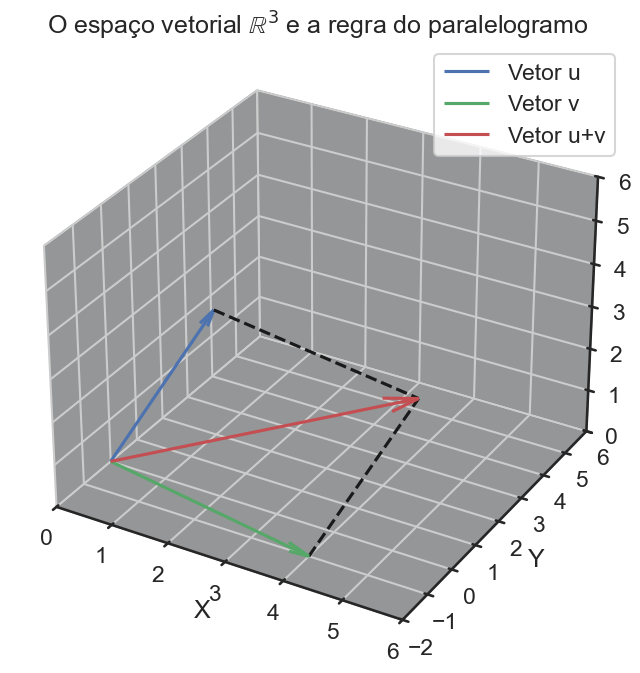

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="talk", palette="deep")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

origem = [0, 0, 0]

ax.quiver(*origem, *u, color='b', label='Vetor u', arrow_length_ratio=0.1)
ax.quiver(*origem, *v, color='g', label='Vetor v', arrow_length_ratio=0.1)
ax.quiver(*origem, *soma, color='r', label='Vetor u+v', arrow_length_ratio=0.1)

ax.plot([u[0], soma[0]], [u[1], soma[1]], [u[2], soma[2]], 'k--')
ax.plot([v[0], soma[0]], [v[1], soma[1]], [v[2], soma[2]], 'k--')

ax.set_xlim([0, 6])
ax.set_ylim([-2, 6])
ax.set_zlim([0, 6])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(r"O espaço vetorial $\mathbb{R}^3$ e a regra do paralelogramo")
ax.legend()
plt.show()

---
## Próximo Passo

Parabéns por concluir este tutorial! Vimos que espaços vetoriais generalizam a noção de vetores para matrizes e polinômios. No próximo passo, vamos mergulhar nos **Subespaços**, onde aprenderemos sobre alicerces teóricos que conservam todas as propriedades estruturais da Álgebra Linear.

👉 **[Ir para o Tutorial 06: Combinação Linear e Span](./06_combinacao_linear_e_span.ipynb)**

---
> **"Linear algebra is the mathematics of the 21st century."** — *Stephen Boyd*